In [43]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import inspect

sp.init_printing("mathjax")

# Finding the functions needed for RK4 simulation

In [44]:
Rcm, rcm, I1, I2, m1, m2, l, g, t = sp.symbols("R_{cm} r_{cm} I_1 I_2 m_1 m_2 l g t")

theta = sp.Function("\\theta")(t)
phi = sp.Function("\\phi")(t)

theta_d = sp.diff(theta, t)
phi_d = sp.diff(phi, t)

all_variables = (theta, theta_d, phi, phi_d, Rcm, rcm, I1, I2, m1, m2, l, g)

Defining the Lagrangian

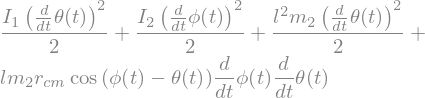

In [45]:
T1 = sp.Rational(1, 2)*I1*theta_d**2
T2 = sp.Rational(1, 2)*m2*l**2*theta_d**2 + sp.Rational(1, 2)*I2*phi_d**2 + m2*l*rcm*theta_d*phi_d*sp.cos(phi-theta)
T = T1 + T2
T_func = sp.lambdify(all_variables, T, "numpy")

V1 = -m1*g*Rcm*sp.cos(theta)
V2 = -m2*g*(l*sp.cos(theta) + rcm*sp.cos(phi))
V = V1 + V2
V_func = sp.lambdify(all_variables, V, "numpy")

L = T - V
T

Finding the equations of motion for $\phi$ and $\theta$

In [46]:
eq_motion_theta = sp.Equality(
    sp.diff(L, theta),
    sp.diff(
        sp.diff(L, theta_d),
        t
    )
)

eq_motion_phi = sp.Equality(
    sp.diff(L, phi),
    sp.diff(
        sp.diff(L, phi_d),
        t
    )
)

Solving for the second derivatives of $\phi$ and $\theta$ in terms of the other variables

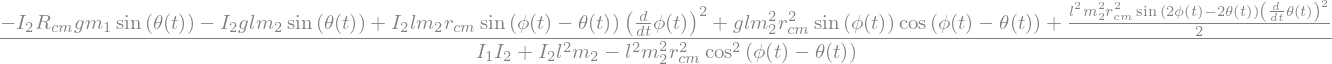

In [47]:
theta_dd = sp.solve(eq_motion_theta, sp.diff(theta_d, t))[0]
phi_dd = sp.solve(eq_motion_phi, sp.diff(phi_d, t))[0]


theta_dd_s = theta_dd.subs(phi_d.diff(t), phi_dd)
phi_dd_s = phi_dd.subs(theta_d.diff(t), theta_dd)

# equations for the second derivative of theta and phi as a function of theta, phi, and their derivatives
theta_dd_s = sp.solve(theta_dd_s - theta_d.diff(t), theta_d.diff(t))[0].simplify()
phi_dd_s = sp.solve(phi_dd_s - phi_d.diff(t), phi_d.diff(t))[0].simplify()

theta_dd_s

Compiling the above expressions into python functions which are quick to compute

In [48]:
tdd = sp.lambdify(all_variables, theta_dd_s, "numpy")
pdd = sp.lambdify(all_variables, phi_dd_s, "numpy")

inspect.getsource(tdd).replace("_lambdifygenerated", "tdd")

'def tdd(_Dummy_194, _Dummy_192, _Dummy_195, _Dummy_193, Dummy_197, Dummy_196, I_1, I_2, m_1, m_2, l, g):\n    return (-1/2*_Dummy_192**2*Dummy_196**2*l**2*m_2**2*sin(2*_Dummy_194 - 2*_Dummy_195) - _Dummy_193**2*Dummy_196*I_2*l*m_2*sin(_Dummy_194 - _Dummy_195) + Dummy_196**2*g*l*m_2**2*sin(_Dummy_195)*cos(_Dummy_194 - _Dummy_195) - Dummy_197*I_2*g*m_1*sin(_Dummy_194) - I_2*g*l*m_2*sin(_Dummy_194))/(-Dummy_196**2*l**2*m_2**2*cos(_Dummy_194 - _Dummy_195)**2 + I_1*I_2 + I_2*l**2*m_2)\n'

# RK4 Simulation

Setting up

In [49]:
# Pendulum parameters, I'll say this one has two bars of uniform mass
Rcm_sim=0.5; rcm_sim=0.5;
m1_sim=1; m2_sim=1; 
l_sim=1; g_sim=9.81
I1_sim=1/3*m1_sim*l_sim**2; I2_sim=1/3*m2_sim*(2*rcm_sim)**2;

# initial condition
y = np.array([np.pi + 0.1, 0, -0.7, 0])

# function relating y to y'
def f(y, t):
    return np.array([
        y[1],
        tdd(y[0], y[1], y[2], y[3], Rcm_sim, rcm_sim, I1_sim, I2_sim, m1_sim, m2_sim, l_sim, g_sim),
        y[3],
        pdd(y[0], y[1], y[2], y[3], Rcm_sim, rcm_sim, I1_sim, I2_sim, m1_sim, m2_sim, l_sim, g_sim)
    ])

# time step between simulation frames
h = 0.05

# current time in the simulation
t = 0

Performing the simulation

In [50]:
past_positions = np.array(y)

for i in range(5000):
    k1 = h*f(y, t)
    k2 = h*f(y + k1/2, t + h/2)
    k3 = h*f(y + k2/2, t + h/2)
    k4 = h*f(y + k3, t + h)

    y = y + k1/6 + k2/3 + k3/3 + k4/6

    past_positions = np.vstack([past_positions, y])

Getting the positions of the ends of the arms. Note: I'm now assuming the arms are a solid bar.

In [51]:
theta_sim = past_positions[:, 0]
theta_d_sim = past_positions[:, 1]
x1_sim = l_sim*np.sin(theta_sim)
y1_sim = -l_sim*np.cos(theta_sim)

phi_sim = past_positions[:, 2]
phi_d_sim = past_positions[:, 3]
x2_sim = x1_sim + 2*rcm_sim*np.sin(phi_sim)
y2_sim = y1_sim - 2*rcm_sim*np.cos(phi_sim)

T_sim = T_func(theta_sim, theta_d_sim, phi_sim, phi_d_sim, Rcm_sim, rcm_sim, I1_sim, I2_sim, m1_sim, m2_sim, l_sim, g_sim)
V_sim = V_func(theta_sim, theta_d_sim, phi_sim, phi_d_sim, Rcm_sim, rcm_sim, I1_sim, I2_sim, m1_sim, m2_sim, l_sim, g_sim)

E_sim = T_sim + V_sim

print("Energy lost in the simulation: " + str(np.max(E_sim)) + "J to " + str(np.min(E_sim)) + "J")

Energy lost in the simulation: 10.890511728972388J to -16.505700142562137J


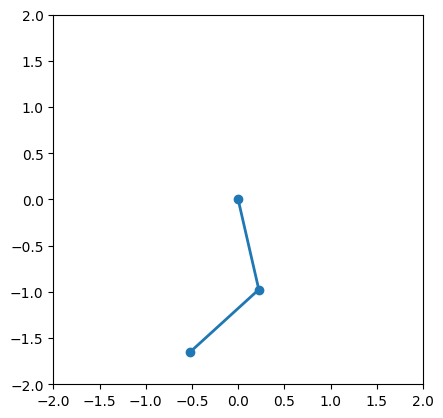

In [52]:
animation_size = (l_sim + 2*rcm_sim)
fig, ax1 = plt.subplots()

# Subplot 1: Pendulum visualization
ax1.set_aspect('equal')
ax1.set_xlim(-animation_size, animation_size)
ax1.set_ylim(-animation_size, animation_size)

line, = ax1.plot([], [], "o-", lw=2, label="Pendulum")

def init():
    line.set_data([], [])
    return line,

def update(i):
    this_x = [0, x1_sim[i], x2_sim[i]]
    this_y = [0, y1_sim[i], y2_sim[i]]

    line.set_data(this_x, this_y)
    return line,

ani = FuncAnimation(fig, update, frames=len(theta_sim), init_func=init, blit=True, interval=1/h)

ani.save("test.mp4")